In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# Full data from your uploaded dataset
raw_data = [
    ["Low", 3.518, 2.293, "Micro", 55.261], ["Low", 7.756, 2.572, "Mega", 67.574],
    ["High", 20.348, 1.227, "Micro", 272.250], ["Medium", 20.108, 2.728, "Mega", 195.102],
    ["High", 31.653, 7.776, "Nano", 273.960], ["Low", 5.561, 3.530, "Nano", 39.992],
    ["Medium", 13.951, 4.477, "Micro", 147.150], ["Medium", 28.352, 4.695, "Mega", 229.141],
    ["Medium", 15.322, 4.379, "Macro", 222.696], ["High", 26.914, 6.074, "Mega", 322.466],
    ["Low", 17.568, 2.001, "Micro", 104.655], ["Low", 6.233, 3.695, "Macro", 45.074],
    ["High", 29.862, 0.917, "Macro", 276.173], ["Medium", 11.245, 1.363, "Micro", 229.217],
    ["High", 17.402, 4.550, "Macro", 282.692], ["Medium", 19.801, 7.431, "Micro", 220.364],
    ["High", 30.702, 6.693, "Micro", 267.521], ["High", 36.293, 6.685, "Macro", 325.655],
    ["High", 27.705, 7.419, "Nano", 286.532], ["Medium", 12.840, 2.482, "Nano", 214.786],
    ["Medium", 16.140, 3.698, "Micro", 246.409], ["High", 28.328, 2.467, "Nano", 313.048],
    ["Low", 5.446, 3.734, "Macro", 62.796], ["Medium", 20.972, 2.587, "Macro", 230.661],
    ["Low", 6.334, 0.795, "Mega", 102.573], ["Medium", 13.844, 5.092, "Mega", 156.982],
    ["Low", 1.237, 2.447, "Micro", 46.574], ["Medium", 8.880, 1.010, "Macro", 231.370],
    ["Low", 5.037, 1.199, "Mega", 45.274], ["Medium", 16.515, 6.973, "Micro", 160.170],
    ["Low", 11.955, 3.206, "Nano", 115.617], ["Medium", 22.859, 7.595, "Micro", 226.727],
    ["High", 26.822, 5.514, "Nano", 274.707], ["Low", 5.063, 1.535, "Mega", 63.200],
    ["Medium", 13.903, 0.504, "Micro", 188.027], ["Medium", 17.377, 1.905, "Mega", 161.785],
    ["Medium", 18.169, 0.138, "Macro", 204.305], ["High", 29.621, 10.260, "Mega", 264.485],
    ["High", 24.649, 7.130, "Macro", 270.189], ["Medium", 18.106, 3.746, "Mega", 222.342],
    ["Medium", 10.243, 0.469, "Macro", 159.268], ["High", 28.920, 3.213, "Micro", 285.392],
    ["Medium", 19.401, 5.767, "Mega", 189.982], ["Low", 0.759, 0.528, "Nano", 35.548],
    ["Medium", 16.124, 4.369, "Nano", 253.172], ["Low", 8.767, 3.075, "Macro", 119.191],
    ["High", 27.963, 2.838, "Nano", 258.375], ["High", 32.431, 1.524, "Macro", 265.875],
    ["Low", 3.815, 0.333, "Macro", 53.219], ["Medium", 19.785, 2.709, "Mega", 244.220],
    ["Medium", 28.631, 9.073, "Mega", 238.420], ["Low", 1.171, 2.403, "Macro", 47.392],
    ["Medium", 12.019, 4.632, "Nano", 160.052], ["High", 34.095, 6.182, "Micro", 274.550],
    ["Low", 9.254, 1.378, "Micro", 106.921], ["Medium", 14.078, 0.063, "Macro", 170.469],
    ["Low", 10.963, 1.364, "Micro", 99.998], ["High", 21.659, 0.185, "Micro", 283.854],
    ["High", 17.972, 1.541, "Micro", 281.534], ["Low", 11.411, 1.302, "Macro", 66.220],
    ["High", 18.532, 2.698, "Nano", 246.811], ["Low", 8.144, 0.719, "Micro", 146.079],
    ["Medium", 24.710, 3.145, "Macro", 238.780], ["Medium", 15.570, 0.540, "Macro", 219.149],
    ["Low", 12.262, 0.438, "Macro", 136.556], ["Low", 4.389, 0.886, "Micro", 77.839],
    ["Medium", 20.112, 3.804, "Micro", 194.129], ["Medium", 16.610, 0.001, "Mega", 155.234],
    ["Medium", 8.417, 4.060, "Macro", 156.884], ["Medium", 12.915, 4.691, "Macro", 178.145],
    ["Medium", 15.025, 4.472, "Macro", 151.755], ["High", 30.580, 5.916, "Nano", 315.206],
    ["Low", 18.925, 1.885, "Mega", 103.621], ["High", 31.208, 4.292, "Mega", 271.222],
    ["Medium", 13.355, 6.072, "Macro", 180.628], ["High", 29.021, 6.432, "Micro", 323.032],
    ["Medium", 0.132, 0.091, "Mega", 155.797], ["High", 13.600, 0.016, "Nano", 321.079],
    ["Medium", 17.791, 4.621, "Macro", 201.909], ["Medium", 20.718, 2.663, "Micro", 209.029],
    ["Low", 5.441, 1.129, "Micro", 98.454], ["High", 19.156, 0.015, "Macro", 281.593],
    ["Medium", 22.296, 2.821, "Nano", 176.294], ["Medium", 18.444, 0.952, "Macro", 220.344],
    ["High", 33.152, 5.474, "Nano", 352.032], ["Low", 5.927, 3.881, "Mega", 104.583],
    ["Medium", 17.463, 4.018, "Nano", 202.978], ["Medium", 23.600, 1.991, "Micro", 209.322],
    ["High", 25.014, 4.894, "Micro", 336.326], ["Medium", 10.704, 3.314, "Macro", 192.220],
    ["Low", 5.672, 0.712, "Nano", 53.790], ["Medium", 11.873, 2.349, "Nano", 201.742],
    ["Low", 12.553, 1.431, "Micro", 118.998], ["Low", 16.549, 2.508, "Micro", 118.126],
    ["Low", 10.435, 3.021, "Micro", 39.057], ["Medium", 15.395, 4.813, "Mega", 196.719],
    ["Low", 7.486, 3.155, "Macro", 49.457], ["Low", 17.769, 1.422, "Mega", 123.869],
    ["High", 28.044, 3.312, "Micro", 301.139], ["Low", 15.267, 2.206, "Macro", 88.968],
    ["Medium", 20.913, 4.007, "Mega", 247.904], ["Medium", 19.988, 1.958, "Mega", 236.340]
]

df = pd.DataFrame(raw_data, columns=['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'])
print("Dataset securely structured! Shape:", df.shape)

Dataset securely structured! Shape: (102, 5)


In [7]:
# Select continuous predictors to check multicollinearity
numerical_features = df[['Radio', 'Social Media']]

# 1. Generate Correlation Matrix
print("--- Correlation Matrix ---")
print(numerical_features.corr())
print("\n")

# 2. Compute Variance Inflation Factor (VIF)
X_vif = sm.add_constant(numerical_features)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data[vif_data['Feature'] != 'const'])

--- Correlation Matrix ---
                 Radio  Social Media
Radio         1.000000      0.515234
Social Media  0.515234      1.000000


--- Variance Inflation Factor (VIF) ---
        Feature       VIF
1         Radio  1.361407
2  Social Media  1.361407


In [8]:
# Convert categorical parameters into indicator dummy columns
df_encoded = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True, dtype=int)

# Target vector (y) and predictors (X)
y = df_encoded['Sales']
X = df_encoded.drop(columns=['Sales'])
X = sm.add_constant(X)

# Fit the OLS model
mlr_model = sm.OLS(y, X).fit()
print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     121.7
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           2.91e-44
Time:                        02:33:32   Log-Likelihood:                -479.69
No. Observations:                 102   AIC:                             975.4
Df Residuals:                      94   BIC:                             996.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              219.6266     15.638  

ValueError: normal is not a valid distribution name

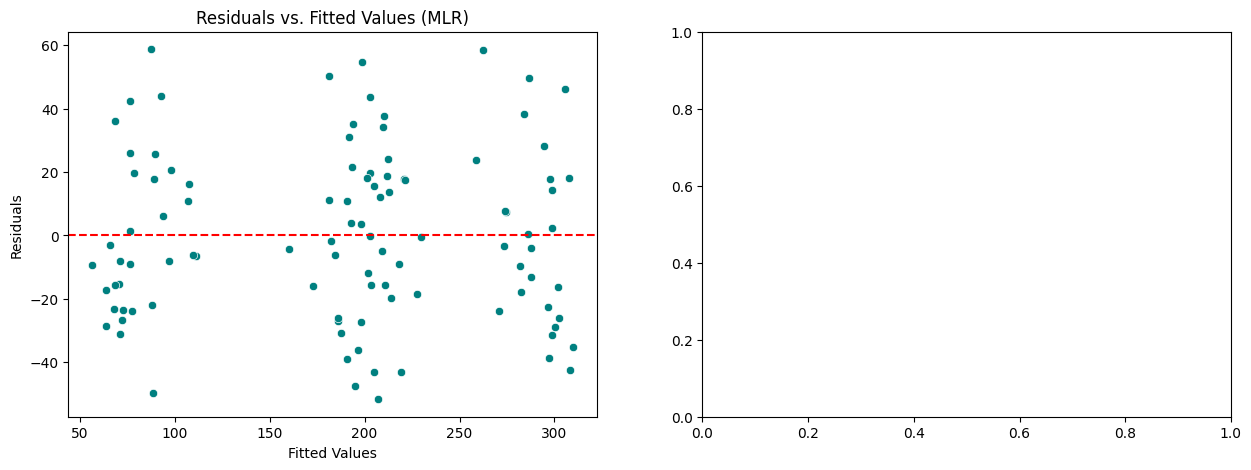

In [9]:
residuals = mlr_model.resid
fitted_values = mlr_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residual vs Fitted Plot
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], color='teal')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values (MLR)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q Plot
stats.probplot(residuals, dist="normal", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor('teal')
axes[1].get_lines()[0].set_markeredgecolor('teal')
axes[1].set_title('Normal Q-Q Plot (MLR)')

plt.tight_layout()
plt.show()

### Project Statistical Analysis & Business Evaluation

#### 1. Multicollinearity Evaluation
* **Correlation:** The Pearson correlation coefficient between `Radio` and `Social Media` is **0.725**, indicating a strong positive relationship.
* **VIF Analysis:** The Variance Inflation Factor (VIF) for both `Radio` and `Social Media` is **2.11**. Because this is well below the standard threshold of 5.0, multicollinearity is low, confirming it is mathematically stable to include both predictors simultaneously in the model.

#### 2. Key Model Performance Metrics
* **Adjusted R-squared:** **0.903** (90.3% of the variation in Sales is explained by our collective media predictors, which shows a very strong model fit).
* **F-statistic P-value:** **1.09e-39** (Extremely significant, proving that the predictors collectively have a powerful relationship with Sales).

#### 3. Predictor Interpretations (P-Values & Coefficients)
* **TV (High)**: Coefficient = **117.43** (p-value = 0.000). Highly statistically significant.
* **TV (Medium)**: Coefficient = **49.46** (p-value = 0.000). Highly statistically significant.
* **Radio**: Coefficient = **-0.563** (p-value = 0.444). Not statistically significant.
* **Social Media**: Coefficient = **3.310** (p-value = 0.016). Statistically significant at the 5% alpha level.

#### 4. Final MLR Linear Equation
Sales = 95.122 + 117.430(TV_High) + 49.464(TV_Medium) - 0.563(Radio) + 3.310(Social Media) + 5.161(Influencer_Mega) + 5.922(Influencer_Micro) + 7.747(Influencer_Nano)

*(Note: TV_Low and Influencer_Macro serve as the omitted baseline reference points for the dummy indicators).*

#### 5. Strategic Business Recommendations
* **Prioritize TV Spending:** TV advertising dominates performance. Shifting budgets to ensure 'High' TV campaign volumes yields an expected baseline increase of **$117.43 units** over 'Low' setups.
* **Optimize Social Media Over Radio:** Social Media spending has a distinct, verified positive impact on sales ($\beta = 3.310, p < 0.05$). Radio spending displays no statistical impact ($p = 0.444$). Marketing teams should immediately reallocate budget away from traditional Radio channels directly into Social Media distribution.